In [36]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import expon
from lifelines import WeibullAFTFitter

df = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\FullIndicatorMatrix.csv')
df['date'] = pd.to_datetime(df['date'])
df.sort_values(by=['indicator', 'date'], inplace=True)
df[df['indicator'] == '146.71.50.198']

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
0,818860012482918321,2024-01-01,146.71.50.198,0,0,False,1,1,0
222,818860012482918321,2024-01-02,146.71.50.198,0,1,False,2,1,0
444,818860012482918321,2024-01-03,146.71.50.198,0,2,False,3,1,0
666,818860012482918321,2024-01-04,146.71.50.198,0,3,False,4,1,0
888,818860012482918321,2024-01-05,146.71.50.198,0,4,False,5,1,0
...,...,...,...,...,...,...,...,...,...
111444,818860012482918321,2025-05-17,146.71.50.198,0,5,True,17,5,0
111666,818860012482918321,2025-05-18,146.71.50.198,0,6,True,18,5,0
111888,818860012482918321,2025-05-19,146.71.50.198,0,0,False,19,5,0
112110,818860012482918321,2025-05-20,146.71.50.198,0,1,False,20,5,0


In [21]:
# Function to extract features per indicator
def extract_time_series_features(group):
    series = group['seen'].values
    dates = group['date'].values

    indices = np.where(series == 1)[0]
    if len(indices) == 0:
        return pd.Series({
            'last_seen': len(series),
            'freq_7': 0,
            'freq_30': 0,
            'avg_gap': len(series),
            'burstiness': 0,
            'label_7': 0,
            'label_14': 0,
            'label_30': 0
        })

    last_seen = len(series) - 1 - indices[-1]
    freq_7 = np.sum(series[-7:])
    freq_30 = np.sum(series[-30:])
    gaps = np.diff(indices)
    avg_gap = np.mean(gaps) if len(gaps) > 0 else len(series)
    burstiness = (np.std(gaps) - avg_gap) / (np.std(gaps) + avg_gap) if len(gaps) > 1 else 0
    label_7 = 1 if np.any(series[-7:]) else 0
    label_14 = 1 if np.any(series[-14:]) else 0
    label_30 = 1 if np.any(series[-30:]) else 0

    return pd.Series({
        'last_seen': last_seen,
        'freq_7': freq_7,
        'freq_30': freq_30,
        'avg_gap': avg_gap,
        'burstiness': burstiness,
        'label_7': label_7,
        'label_14': label_14,
        'label_30': label_30
    })

# Apply to each indicator group
features_df = df.groupby('indicator').apply(extract_time_series_features).reset_index()

C:\Users\jaskew\AppData\Local\Temp\ipykernel_22212\74051210.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features_df = df.groupby('indicator').apply(extract_time_series_features).reset_index()


In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from lifelines import WeibullAFTFitter
from scipy.stats import expon
import numpy as np
from datetime import datetime

# Copy features into a separate DataFrame for modeling
df_pred = features_df.copy()

# Define features and labels
X = df_pred[['last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness']]
y_7 = df_pred['label_7']
y_14 = df_pred['label_14']
y_30 = df_pred['label_30']

# Helper functions
def safe_train_predict(model_cls, X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = Pipeline([('scaler', StandardScaler()), ('clf', model_cls())])
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

def safe_train_gbt(X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = GradientBoostingClassifier()
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

# Logistic Regression Predictions
df_pred['logistic_7'] = safe_train_predict(LogisticRegression, X, y_7)
df_pred['logistic_14'] = safe_train_predict(LogisticRegression, X, y_14)
df_pred['logistic_30'] = safe_train_predict(LogisticRegression, X, y_30)

# Gradient Boosted Tree Predictions
df_pred['gbt_7'] = safe_train_gbt(X, y_7)
df_pred['gbt_14'] = safe_train_gbt(X, y_14)
df_pred['gbt_30'] = safe_train_gbt(X, y_30)

# Exponential Model (Poisson-based)
rate = (df_pred['freq_30'] / 30).clip(lower=1e-6)
df_pred['exp_7'] = 1 - np.exp(-rate * 7)
df_pred['exp_14'] = 1 - np.exp(-rate * 14)
df_pred['exp_30'] = 1 - np.exp(-rate * 30)

# Weibull AFT Model
aft_df = X.copy()
aft_df['duration'] = df_pred['avg_gap']
aft_df['event'] = y_7

aft = WeibullAFTFitter()
aft.fit(aft_df, duration_col='duration', event_col='event')

# Predict survival function at 1, 7, 14, 30 days
surv_func = aft.predict_survival_function(aft_df, times=[1, 7, 14, 30])
df_pred['weibull_today'] = 1 - surv_func.loc[1].values
df_pred['weibull_7'] = 1 - surv_func.loc[7].values
df_pred['weibull_14'] = 1 - surv_func.loc[14].values
df_pred['weibull_30'] = 1 - surv_func.loc[30].values

# Today's forecast
df_pred['exp_today'] = 1 - np.exp(-rate * 1)
df_pred['logistic_today'] = safe_train_predict(LogisticRegression, X, y_7)
df_pred['gbt_today'] = safe_train_gbt(X, y_7)

# Merge in actual "seen" value for today's date
latest_date = df['date'].max()
today_seen = df[df['date'] == latest_date][['indicator', 'seen']].rename(columns={'seen': 'seen_today'})
df_pred = df_pred.merge(today_seen, on='indicator', how='left')

# Final output
output = df_pred[[
    'indicator', 'seen_today', 'last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness',
    'exp_today', 'exp_7', 'exp_14', 'exp_30',
    'weibull_today', 'weibull_7', 'weibull_14', 'weibull_30',
    'logistic_today', 'logistic_7', 'logistic_14', 'logistic_30',
    'gbt_today', 'gbt_7', 'gbt_14', 'gbt_30'
]]

display(output)


,indicator,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
0,102.129.153.158,0,54.0,0.0,0.0,21.000000,0.000000,9.999995e-07,0.000007,0.000014,...,7.819743e-07,0.000005,0.004853,0.004853,0.004920,0.060144,0.000012,0.000012,0.000018,0.000025
1,102.129.153.43,0,5.0,1.0,2.0,31.000000,-0.352092,6.449301e-02,0.372911,0.606759,...,2.027090e-01,0.734342,0.799786,0.799786,0.896591,0.984610,0.999969,0.999969,0.999974,0.999982
2,102.129.153.71,0,27.0,0.0,1.0,18.666667,-0.235250,3.278390e-02,0.208110,0.372911,...,8.648641e-04,0.005050,0.034188,0.034188,0.124116,0.712979,0.000012,0.000012,0.000018,0.999982
3,102.165.16.161,0,41.0,0.0,0.0,6.000000,-0.381966,9.999995e-07,0.000007,0.000014,...,1.928217e-05,0.000113,0.014793,0.014793,0.022704,0.252910,0.000012,0.000012,0.000018,0.000025
4,104.160.6.2,0,28.0,0.0,2.0,20.500000,-0.025000,6.449301e-02,0.372911,0.606759,...,1.044484e-03,0.006096,0.028904,0.028904,0.129812,0.753891,0.000012,0.000012,0.000018,0.999982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,international.standardbank.com/,0,120.0,0.0,0.0,507.000000,0.000000,9.999995e-07,0.000007,0.000014,...,0.000000e+00,0.000000,0.000092,0.000092,0.000002,0.000016,0.000012,0.000012,0.000018,0.000025
218,pub.marq.com/,0,7.0,0.0,1.0,9.600000,0.122880,3.278390e-02,0.208110,0.372911,...,2.263165e-01,0.777186,0.089758,0.089758,0.593824,0.960236,0.000012,0.000012,0.999974,0.999982
219,realinvestmentadvice.com/,0,2.0,1.0,4.0,8.909091,-0.025342,1.248267e-01,0.606759,0.845362,...,8.154396e-01,0.999949,0.804956,0.804956,0.946055,0.994642,0.999969,0.999969,0.999974,0.999982
220,www.emergencylighting.com/,1,0.0,1.0,1.0,37.333333,0.072579,3.278390e-02,0.208110,0.372911,...,5.917915e-01,0.994714,0.793146,0.793146,0.927358,0.985660,0.999969,0.999969,0.999974,0.999982


In [44]:
output[output['indicator'] == '102.129.153.158']

,indicator,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,exp_30,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
0,102.129.153.158,54.0,0.0,0.0,21.0,0.0,9.999995e-07,0.000007,0.000014,0.00003,...,7.819743e-07,0.000005,0.004853,0.004853,0.00492,0.060144,0.000012,0.000012,0.000018,0.000025


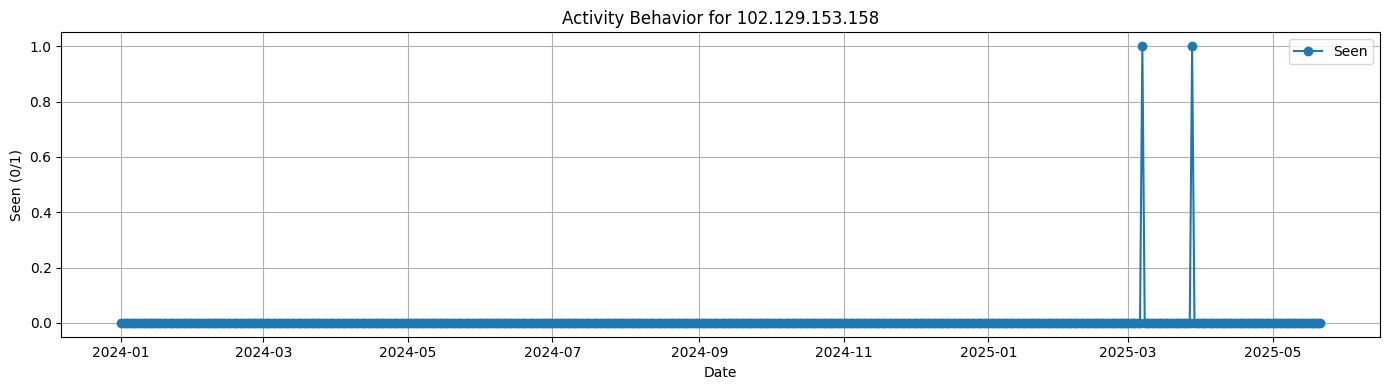

In [46]:
import matplotlib.pyplot as plt

indicator_id = '102.129.153.158'
df_plot = df[df['indicator'] == indicator_id].sort_values('date')

plt.figure(figsize=(14, 4))
plt.plot(df_plot['date'], df_plot['seen'], marker='o', linestyle='-', label='Seen')
plt.title(f'Activity Behavior for {indicator_id}')
plt.xlabel('Date')
plt.ylabel('Seen (0/1)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [64]:
output[output['indicator'] == '113.96.236.11']

,indicator,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,exp_30,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
12,113.96.236.11,62.0,0.0,0.0,1.75,-0.357033,9.999995e-07,0.000007,0.000014,0.00003,...,9.471703e-08,5.542254e-07,0.003734,0.003734,0.001978,0.027308,0.000012,0.000012,0.000018,0.000025


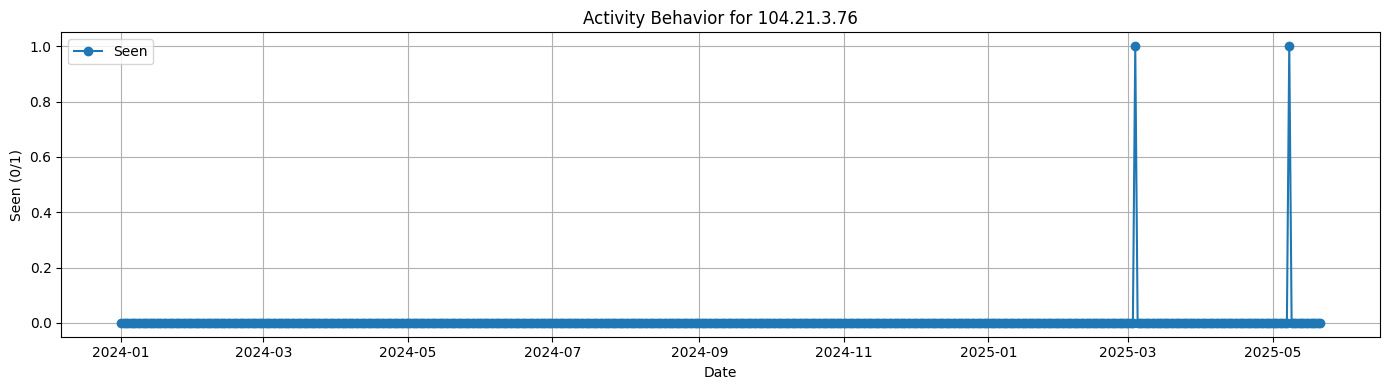

In [63]:
indicator_id = '104.21.3.76'
df_plot = df[df['indicator'] == indicator_id].sort_values('date')

plt.figure(figsize=(14, 4))
plt.plot(df_plot['date'], df_plot['seen'], marker='o', linestyle='-', label='Seen')
plt.title(f'Activity Behavior for {indicator_id}')
plt.xlabel('Date')
plt.ylabel('Seen (0/1)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [57]:
df[(df['seen'] ==0) & (df['date'] == pd.Timestamp('2025-05-21'))]

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
112493,818860012482918321,2025-05-21,102.129.153.158,0,2,False,21,5,0
112476,818860012482918321,2025-05-21,102.129.153.43,0,2,False,21,5,0
112344,818860012482918321,2025-05-21,102.129.153.71,0,2,False,21,5,0
112494,818860012482918321,2025-05-21,102.165.16.161,0,2,False,21,5,0
112499,818860012482918321,2025-05-21,104.160.6.2,0,2,False,21,5,0
...,...,...,...,...,...,...,...,...,...
112359,818860012482918321,2025-05-21,geo.netsupportsoftware.com/location/loca.asp,0,2,False,21,5,0
112487,818860012482918321,2025-05-21,hcmiu.edu.vn/,0,2,False,21,5,0
112443,818860012482918321,2025-05-21,international.standardbank.com/,0,2,False,21,5,0
112521,818860012482918321,2025-05-21,pub.marq.com/,0,2,False,21,5,0
